In [453]:
import gymnasium as gym
import numpy as np
from IPython.display import display, clear_output, Image
import time
from PIL import Image
import time
from collections import deque
import random
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

In [79]:
# env = gym.make('LunarLander-v3', render_mode='rgb_array')
env = gym.make('LunarLander-v3', render_mode='human')
# env = env.unwrapped

def render_frame(env):
    frame = env.render()
    # image = Image.fromarray(frame)
    # display(image)
    
state, info = env.reset()
render_frame(env)

In [71]:
print(env.action_space)
print(env.observation_space.shape)

Discrete(4)
(8,)


In [574]:
env.unwrapped.render_mode = 'human'

state, info = env.reset()
for step in range(999):
    clear_output(wait=True)
    render_frame(env)

    action = env.action_space.sample()
    state, reward, done, truncated, info = env.step(action)
    print('taking action', action, ' got reward', reward)

    if done or truncated:
        print(f"Episode finished with environment reward: {reward}")
        break

taking action 1  got reward -100
Episode finished with environment reward: -100


# collect training data and train
render_mode set to None

In [586]:
# action idx mapping, 0:NOOP 1:left 2:main 3:right
class Network(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(8, 64)  # fully connected layers
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 4)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)  # raw logits are predicted Q values
        return x
        

# create a TargetQNet as well for stability
# QNet will be copied into TargetQNet periodically (maybe every 1000 steps)
QNet = Network()  # updated every step
TargetQNet = Network()  # produces targets that are used to update QNet

def sync(): 
    TargetQNet.load_state_dict(QNet.state_dict())
    
def soft_sync(tau):
    for target_param, q_param in zip(TargetQNet.parameters(), QNet.parameters()):
        target_param.data.copy_(tau*q_param.data + (1-tau)*target_param.data)

sync()

In [587]:
def epsilon_greedy(eps):
    if np.random.random() < eps:
        return env.action_space.sample()  # random action with prob epsilon
    with torch.no_grad():  # don't track backward gradients on inference
        x = torch.tensor(state)
        q_values = QNet(x)  # same as QNet.forward(x)
        return q_values.argmax().item()  # greedy action

In [588]:
gamma = 0.995      # discount factor
buf_sz = 50_000    # max capacity of replay buffer
learn_freq = 4     # do a learning update every X steps
sync_freq = 4      # sync the target network with the Q network every X steps
batch_sz = 64      # mini-batch size
min_buf_sz = 1024  # start training after X samples are in replay buffer
max_steps = 900    # terminate env if it ever reaches X time steps (keeps episode times resonable)

optimizer = optim.Adam(QNet.parameters(), lr=0.001)  # optimizer choice and learning rate
L = nn.MSELoss()  # loss, probably MSE is best, note that MSELoss calculates mean element-wise diffs

# epsilon-greedy annealing
eps_init = 1
eps_final = 0.01
eps_decay = 100000  # decay over X steps

episode 1998	(3.1/s)
steps 833453	(1290/s)
time 646.21 s
epsilon 0.01


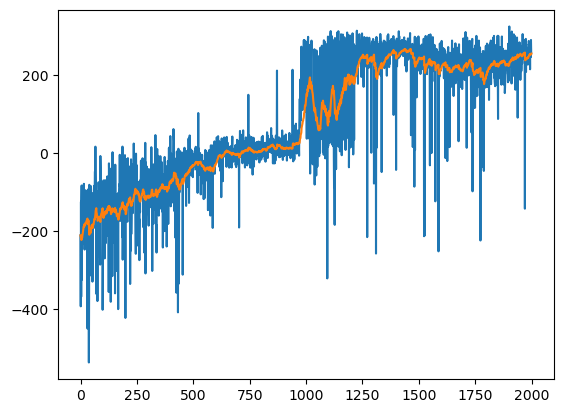

In [589]:
replay_buf = deque(maxlen=buf_sz) # 5-tuple (state, action, reward, next_state, done)

env.unwrapped.render_mode = None
t0 = time.time()
total_steps = 0

return_history = []
avg_history = []  # moving average of return
avg_beta = 0.95

for episode in range(2000):
    state, info = env.reset()
    return_ = 0
    steps = 0
    while True:
        eps = max(eps_final, eps_init - total_steps / eps_decay)
        action = epsilon_greedy(eps)
        next_state, reward, done, truncated, info = env.step(action)
        if steps > max_steps: truncated = True  # 'truncated' not 'done' so it doesn't corrupt replay buffer!!
        replay_buf.append((state, action, reward, next_state, done))
        steps += 1
        total_steps += 1
        return_ += reward

        if total_steps % sync_freq == 0: 
            soft_sync(0.001)  # update the target network

        if len(replay_buf) >= min_buf_sz and total_steps % learn_freq == 0:
            batch = random.sample(replay_buf, batch_sz)  # remember, this is a batch of many 5-tuples
            states, actions, rewards, next_states, dones = zip(*batch)  # unpack, pack, unpack into desired vars
            
            states_tensor = torch.tensor(states, dtype=torch.float)                   # shape (m, |S|) where m=batch_sz
            actions_tensor = torch.tensor(actions, dtype=torch.float).reshape(-1, 1)  # shape (1, m)
            rewards_tensor = torch.tensor(rewards, dtype=torch.float).reshape(-1, 1)  # shape (1, m)
            next_states_tensor = torch.tensor(next_states, dtype=torch.float)         # shape (m, |S|)
            dones_tensor = torch.tensor(dones, dtype=torch.float).reshape(-1, 1)      # shape (1, m)

            # forward pass outputs includes Q values for all actions but we only observe the choosen action, so gather along columns
            Q_pred = QNet(states_tensor).gather(1, actions_tensor.type(torch.LongTensor))  # gather needs LongTensor to work

            with torch.no_grad():  # disable backward gradient tracking since we never backprop on the target network
                next_Q_values = TargetQNet(next_states_tensor)  # includes all Q(s', a')
                max_next_Q = next_Q_values.max(dim=1, keepdim=True)[0]
                
                # y = R(s) + \gamma * max_next_Q  [if non-terminal]
                # y = R(s)  [if terminal - i.e. when 'done' is True]
                y = rewards_tensor + gamma * max_next_Q * (1 - dones_tensor)
                
            loss = L(Q_pred, y)
            
            optimizer.zero_grad()
            loss.backward()
            # nn.utils.clip_grad_norm_(QNet.parameters(), max_norm=1.0)  # clip grads - maybe not necessary
            optimizer.step()
            
        state = next_state
        if done or truncated: break
        
    return_history.append(return_)
    if not avg_history: avg_history.append(return_)  # initialize with 1 element
    avg_history.append(avg_history[-1] * avg_beta + (1-avg_beta) * return_)
    
    if episode % 3 == 0:
        t = time.time() - t0
        clear_output(wait=True)
        print(f'episode {episode}\t({episode/t :.1f}/s)')
        print(f'steps {total_steps}\t({total_steps/t :.0f}/s)')
        print(f'time {t:.2f} s')
        print(f'epsilon {eps:.2f}')
        
        plt.plot(return_history)
        plt.plot(avg_history)
        plt.show()


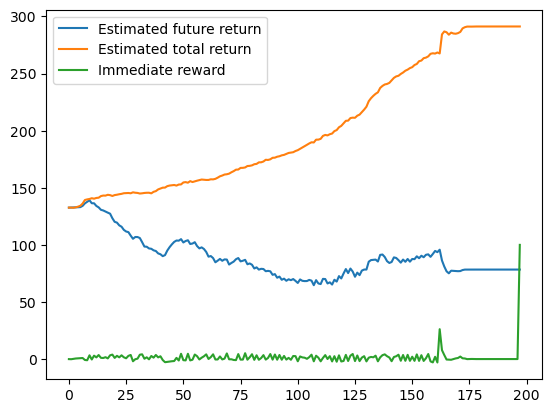

Episode finished with environment reward: 100, total rewards collected: 312.884585971004


In [630]:
# play out an episode with stats!

env.unwrapped.render_mode = 'human'

Q_history = []
reward_history = []
estimated_total_return = []

_cumsum = 0
state, info = env.reset()
for step in range(999):
    render_frame(env)

    with torch.no_grad():
        x = torch.tensor(state)
        q_values = QNet(x)
        action = q_values.argmax().item()  # this action is same as calling epsilon_greedy(eps=0)
        max_Q = q_values.max().item()
        
    state, reward, done, truncated, info = env.step(action)

    Q_history.append(max_Q)
    reward_history.append(reward)
    estimated_total_return.append(_cumsum + max_Q)
    _cumsum += reward

    clear_output(wait=True)
    plt.plot(Q_history, label='Estimated future return')
    plt.plot(estimated_total_return, label='Estimated total return')
    plt.plot(reward_history, label='Immediate reward')
    plt.legend()
    plt.show()

    if done or truncated:
        print(f"Episode finished with environment reward: {reward}, total rewards collected: {_cumsum}")
        break

In [631]:
# save
torch.save(QNet.state_dict(), 'lunarLander-QNet-2k.pth')